# Import statements

In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
import scipy
import sklearn
from scipy.stats import pearsonr
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR

In [3]:
#from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from math import sqrt
import xgboost as xgb
#from sklearn.model_selection import GridSearchCV
import seaborn as sns

In [4]:
import shap

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import tqdm as notebook_tqdm
from skopt import BayesSearchCV
import skopt
from skopt.space import Real, Categorical, Integer
from sklearn.ensemble import RandomForestRegressor

In [6]:
from platform import python_version

print(python_version())



3.10.12


In [4]:
!which python3

/usr/bin/python3


In [8]:
print(np.__version__)

1.26.3


# Load dataset

In [8]:
tt_set = pd.read_pickle("pickle_files/training_data_prt.pkl")

In [9]:
tt_set.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s100_BeiJing_2013,s100,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100_HeNan_2014,s100,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014_BeiJing_2013,s1014,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014_HeNan_2014,s1014,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [10]:
tt_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100_BeiJing_2013 to s99_BeiJing_2013
Columns: 251240 entries, Line to PRT
dtypes: float64(4), int64(251235), object(1)
memory usage: 2.0+ GB


In [11]:
#Final_data= Final_data.drop(['new_line'], axis=1)
tt_set.set_index('Line', inplace=True)
tt_set.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,0,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,0,0,1,0,0,1,1,0,0,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


In [9]:
snps = Final_data.iloc[:, 0:251229]
snps.head()

NameError: name 'Final_data' is not defined

In [18]:
prt = Final_data.iloc[:, 251237:]
prt.head()

,PRT
Line,
s100,340.553
s100,358.104
s1014,366.116
s1014,326.667
s101,385.915


In [12]:
full_pheno = tt_set.iloc[:, 251229:]
full_pheno.head()

,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,
s100,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s1014,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667
s101,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915


# Define all functions

In [13]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

#set parameter space for Random forest models
rf_space = {
    'n_estimators': Integer(50, 500),  # Number of trees
    'max_depth': Integer(3, 50),  # Maximum depth of trees
    'min_samples_split': Integer(2, 20),  # Minimum samples to split a node
    'min_samples_leaf': Integer(1, 10),  # Minimum samples per leaf node
    'max_features': Categorical(['sqrt']),  # Number of features to consider
    'bootstrap': Categorical([True]),  # Use bootstrapping
    'max_samples': Real(0.5, 1.0, 'uniform'),  # Fraction of samples used for training
}

#set parameter space for SVM models
svr_space = {
    'kernel': Categorical(['linear', 'rbf', 'poly', 'sigmoid']),
    'epsilon': Categorical([0.5, 1, 1.5, 2, 2.5, 3]),
}


In [14]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [15]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor()
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 

def bayesian_rfr_search(X, y,rf_space):
    """
    Perform Bayesian hyperparameter tuning for Random forest using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        RFRegressor: Best Random Forest model with tuned parameters.
    """
    rfr = RandomForestRegressor()
    rf_bayes_search = BayesSearchCV(rfr, rf_space, n_iter=32, # specify how many iterations
                                    scoring=None, n_jobs=-1, cv=5, verbose=1, random_state=42, n_points=7 # Use all CPU cores
                                   )
    
    rf_bayes_search.fit(X, y.ravel())
    
    print("Best RF Parameters:",  rf_bayes_search.best_params_)
    
    best_params = rf_bayes_search.best_params_
    best_rfreg = RandomForestRegressor(**best_params)

    return best_rfreg

#TO RUN - best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

def bayesian_svr_search(X, y, svr_space):
    """
    Perform Bayesian hyperparameter tuning for SVR using BayesSearchCV.

    Parameters:
        X (array-like): Feature set.
        y (array-like): Target variable.
        svr_space (dict): Hyperparameter search space for SVR.

    Returns:
        SVR: Best SVR model with tuned parameters.
    """
    svr = SVR()
    svr_bayes_search = BayesSearchCV(
        svr,
        svr_space,
        n_iter=10,
        scoring=None,
        n_jobs=-1,
        cv=5,
        verbose=1,
        random_state=42,
        n_points=2
    )

    svr_bayes_search.fit(X, y.ravel())
    
    print("Best SVR Parameters:", svr_bayes_search.best_params_)
    
    best_params = svr_bayes_search.best_params_
    best_svr = SVR(**best_params)

    return best_svr

#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [16]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, x, y, k):
    #model: xgboost model, should be with the best params available
    #x: input data (eg. all samples and SNPS)
    #y: labels
    #k: number of folds for cross validation
    cv = KFold(n_splits=k,shuffle=True)
  #  fig1 = plt.figure(figsize=[12,12])

   # tprs = []
   # aucs = []
    results = []
   # mean_fpr = np.linspace(0,1,100)
    low = 100
    best = m
    i = 1
    for train,test in cv.split(x,y):
        #print(y[test])
        m.fit(x[train],y[train].ravel())
        print("fitting done. Processing fold accuracy + checking best model")
        #predictions = [round(value) for value in y_pred]
        #sees how accurate the model was when testing the test set
        all_preds = [x for x in m.predict(x[test])]
        ss = sqrt(mean_squared_error(all_preds, y[test]))
        rr = r2_score(all_preds, y[test])
        mm = np.mean(y[test])
        error_mean = ((ss/mm)*100)
        print("R^2 Value is: " + str(rr))
        print("RMSE for dataset is:" +str(ss) + "& mean of this fold is " + str(mm))
        print("this is "+ str((ss/mm)*100) + "% of the mean pheno data")
        if(error_mean < low):
            low = error_mean
            best = m
        results.append(error_mean)
        i= i+1
    print("Training Testing Accuracy: %.2f%% (%.2f%%)" % (np.mean(results), np.std(results)))
    return best

#TO RUN - best_model_xgb = eval_k_fold(model, X, y, 10) or best_model_rfr = eval_k_fold(model, X, y, 10)

In [17]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [18]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = [x for x in best_model.predict(X_holdout)]

    # Compute performance metrics
    ss = sqrt(mean_squared_error(all_preds, y_holdout))
    rr = r2_score(all_preds, y_holdout)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100

    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")

    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    plot_x, plot_y = [], []

    for counter, actual in enumerate(y_holdout):
        if counter <= 5:  # Print first 5 examples
            print(counter, actual, all_preds[counter])
        if all_preds[counter] > 1:
            plot_x.append(actual)
            plot_y.append(all_preds[counter])

    # Create a DataFrame for plotting
    thisplot = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

    # Generate regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()


    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [19]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# GWAS dataset

In [20]:
#Load file
genotype = pd.read_csv('../gwas_prt/top_5percent_snps.012', sep='\t', header=None)
genotype.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Columns: 12562 entries, 0 to 12561
dtypes: int64(12562)
memory usage: 66.7 MB


In [21]:
genotype.head()

,0,1,2,3,4,5,6,7,8,9,...,12552,12553,12554,12555,12556,12557,12558,12559,12560,12561
0,0,0,0,0,1,0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0
1,1,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,2,0,0,0,1,0,0,0,0,0,...,0,1,1,0,0,1,0,0,0,0
3,3,0,0,0,1,1,0,1,1,0,...,0,1,0,0,0,0,0,0,0,1
4,4,0,0,0,0,0,0,0,0,1,...,2,0,0,0,0,0,0,0,0,0


In [22]:
genotype.set_index(genotype.columns[0], inplace =True)
genotype.head()

,1,2,3,4,5,6,7,8,9,10,...,12552,12553,12554,12555,12556,12557,12558,12559,12560,12561
0,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,1,0,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,1,0,0,0,0,0,0,...,0,1,1,0,0,1,0,0,0,0
3,0,0,0,1,1,0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,1,0,...,2,0,0,0,0,0,0,0,0,0


In [23]:
column_names = pd.read_csv('../gwas_prt/id_names_top5.txt', sep=' ', header=None)

In [24]:
column_names.head

<bound method NDFrame.head of                     0
0          Chr1_17750
1         Chr1_130043
2         Chr1_131374
3         Chr1_132416
4         Chr1_213719
...               ...
12556  Chr20_51568577
12557  Chr20_51595684
12558  Chr20_51888995
12559  Chr20_51890470
12560  Chr20_52241655

[12561 rows x 1 columns]>

In [25]:
genotype.columns = column_names
genotype.info()

<class 'pandas.core.frame.DataFrame'>
Index: 696 entries, 0 to 695
Columns: 12561 entries, ('Chr1_17750',) to ('Chr20_52241655',)
dtypes: int64(12561)
memory usage: 66.7 MB


In [26]:
genotype.head()

,"(Chr1_17750,)","(Chr1_130043,)","(Chr1_131374,)","(Chr1_132416,)","(Chr1_213719,)","(Chr1_213749,)","(Chr1_213796,)","(Chr1_213831,)","(Chr1_215314,)","(Chr1_234732,)",...,"(Chr20_51124213,)","(Chr20_51274941,)","(Chr20_51322653,)","(Chr20_51326016,)","(Chr20_51476391,)","(Chr20_51568577,)","(Chr20_51595684,)","(Chr20_51888995,)","(Chr20_51890470,)","(Chr20_52241655,)"
0,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,1,0,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,1,0,0,0,0,0,0,...,0,1,1,0,0,1,0,0,0,0
3,0,0,0,1,1,0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,1,0,...,2,0,0,0,0,0,0,0,0,0


In [27]:
#Adding row names
rows= pd.read_csv('../gwas_prt/top_5percent_indv.txt', header=None)
rows.head()

,0
0,s63
1,s64
2,s66
3,s70
4,s71


In [28]:
genotype.index = rows
genotype.head()

,"(Chr1_17750,)","(Chr1_130043,)","(Chr1_131374,)","(Chr1_132416,)","(Chr1_213719,)","(Chr1_213749,)","(Chr1_213796,)","(Chr1_213831,)","(Chr1_215314,)","(Chr1_234732,)",...,"(Chr20_51124213,)","(Chr20_51274941,)","(Chr20_51322653,)","(Chr20_51326016,)","(Chr20_51476391,)","(Chr20_51568577,)","(Chr20_51595684,)","(Chr20_51888995,)","(Chr20_51890470,)","(Chr20_52241655,)"
"(s63,)",0,0,0,1,0,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,0
"(s64,)",0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
"(s66,)",0,0,0,1,0,0,0,0,0,0,...,0,1,1,0,0,1,0,0,0,0
"(s70,)",0,0,0,1,1,0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,1
"(s71,)",0,0,0,0,0,0,0,0,1,0,...,2,0,0,0,0,0,0,0,0,0


In [29]:
genotype.to_csv('genotype_top5_percent_prt.txt', sep ='\t', index = True)

In [30]:
!sed 's/[,()\x27]//g'  genotype_top5_percent_prt.txt > genotype_top5_percent_prt_new.txt

In [31]:
#Load the genotype data
genotype_new = pd.read_csv('genotype_top5_percent_prt_new.txt', sep = '\t')
genotype_new.head()

,Unnamed: 0,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,...,Chr20_51124213,Chr20_51274941,Chr20_51322653,Chr20_51326016,Chr20_51476391,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655
0,s63,0,0,0,1,0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0
1,s64,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,s66,0,0,0,1,0,0,0,0,0,...,0,1,1,0,0,1,0,0,0,0
3,s70,0,0,0,1,1,0,1,1,0,...,0,1,0,0,0,0,0,0,0,1
4,s71,0,0,0,0,0,0,0,0,1,...,2,0,0,0,0,0,0,0,0,0


In [32]:
genotype_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Columns: 12562 entries, Unnamed: 0 to Chr20_52241655
dtypes: int64(12561), object(1)
memory usage: 66.7+ MB


In [33]:
#Setting the index and naming the index column 
genotype_new = genotype_new.rename(columns={genotype_new.columns[0]: 'Line'})
genotype_new.set_index(genotype_new.columns[0])

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_51124213,Chr20_51274941,Chr20_51322653,Chr20_51326016,Chr20_51476391,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655
Line,,,,,,,,,,,,,,,,,,,,,
s63,0,0,0,1,0,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,0
s64,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
s66,0,0,0,1,0,0,0,0,0,0,...,0,1,1,0,0,1,0,0,0,0
s70,0,0,0,1,1,0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,1
s71,0,0,0,0,0,0,0,0,1,0,...,2,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s2042,0,0,0,0,0,0,0,1,0,0,...,2,1,0,0,0,0,0,0,0,0
s2460,0,0,0,2,0,0,1,0,0,1,...,2,0,1,1,0,0,0,0,0,0
s2513,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,1


In [34]:
full_pheno.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   BBD                1094 non-null   int64  
 1   LW                 1094 non-null   float64
 2   LL                 1094 non-null   float64
 3   PLH                1094 non-null   float64
 4   BeiJing_2013       1094 non-null   int64  
 5   HeNan_2014         1094 non-null   int64  
 6   HeiLongJiang_2014  1094 non-null   int64  
 7   improved_cultivar  1094 non-null   int64  
 8   landrace           1094 non-null   int64  
 9   PRT                1094 non-null   float64
dtypes: float64(4), int64(6)
memory usage: 94.0+ KB


In [35]:
gwas_data = pd.merge(genotype_new, full_pheno, on='Line', how='outer', indicator=False)
gwas_data.head()

,Line,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
0,s100,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
1,s100,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
2,s101,0,0,0,0,0,0,0,1,1,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915
3,s1014,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
4,s1014,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667


In [36]:
gwas_data = gwas_data.set_index('Line')
gwas_data.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s101,0,0,0,0,0,0,0,1,1,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915
s1014,0,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667


In [44]:
gwas_data= gwas_data.drop(['index'], axis=1)

KeyError: "['index'] not found in axis"

In [37]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 12571 entries, Chr1_17750 to PRT
dtypes: float64(4), int64(12567)
memory usage: 104.9+ MB


In [38]:
gwas_data.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,61,6.26667,9.5000,154.700,1,0,0,0,1,340.553
s100,0,0,0,0,0,0,0,0,0,0,...,37,7.19333,10.2200,130.000,0,1,0,0,1,358.104
s101,0,0,0,0,0,0,0,1,1,0,...,62,10.22000,14.2800,95.700,0,0,1,0,1,385.915
s1014,0,0,0,0,0,0,0,0,0,0,...,77,7.76667,10.3667,111.733,1,0,0,0,1,366.116
s1014,0,0,0,0,0,0,0,0,0,0,...,42,7.78667,11.8200,73.000,0,1,0,0,1,326.667


# GWAS all traits

In [39]:
gwas_data.to_pickle("GWAS_top5percent_prt_data.pkl")
#gwas_data = pd.read_pickle("pickle_files/GWAS_top5percent_md_data.pkl")
#gwas_data.head()

In [40]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 12571 entries, Chr1_17750 to PRT
dtypes: float64(4), int64(12567)
memory usage: 104.9+ MB


In [41]:
gwas_y = gwas_data.iloc[:, 12570:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


In [42]:
gwas_all= gwas_data.drop(['PRT'], axis=1)
gwas_all.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_52241655,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s101,0,0,0,0,0,0,0,1,1,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1


In [43]:
gwas_all_dupe= gwas_data.drop(['PRT'], axis=1)
gwas_all_dupe.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_52241655,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,61,6.26667,9.5000,154.700,1,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,0,...,0,37,7.19333,10.2200,130.000,0,1,0,0,1
s101,0,0,0,0,0,0,0,1,1,0,...,0,62,10.22000,14.2800,95.700,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,77,7.76667,10.3667,111.733,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,42,7.78667,11.8200,73.000,0,1,0,0,1


# Run models

In [44]:
X_train, X_test, y_train, y_test = train_test_split(gwas_all, gwas_y, test_size=0.1, random_state=42)

In [45]:
X_train.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_52241655,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s174,0,0,0,0,0,0,0,0,0,0,...,1,35,7.18000,9.62667,42.7000,0,1,0,1,0
s623,0,0,0,1,0,0,0,0,0,1,...,0,57,8.40000,9.20000,63.1000,1,0,0,1,0
s237,0,0,0,0,0,0,0,0,0,0,...,0,45,7.43333,10.36670,106.4670,1,0,0,1,0
s73,0,0,0,0,0,0,0,0,0,0,...,2,66,5.03333,7.73333,99.3333,1,0,0,1,0
s195,0,0,0,0,0,0,0,0,0,0,...,0,64,8.54667,13.18000,44.9400,0,0,1,1,0


In [46]:
X_train = X_train.to_numpy()

In [47]:
y_train = y_train.to_numpy()

In [48]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.6298671229697574), ('colsample_bytree', 0.3205835754834794), ('gamma', 1.1898369595236219e-07), ('learning_rate', 0.036815905609314095), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 200), ('reg_alpha', 1e-09), ('reg_lambda', 2.8062370214110643e-05), ('subsample', 0.17183941680672207)])


In [13]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.6298671229697574), ('colsample_bytree', 0.3205835754834794), ('gamma', 1.1898369595236219e-07), ('learning_rate', 0.036815905609314095), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 200), ('reg_alpha', 1e-09), ('reg_lambda', 2.8062370214110643e-05), ('subsample', 0.17183941680672207)])

In [68]:
#gwas_all = gwas_all.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.35314554252532
RMSE for dataset is:23.597710409866412& mean of this fold is 355.01247272727267
this is 6.647008830023451% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.0843671584406147
RMSE for dataset is:19.42664050461121& mean of this fold is 353.4444181818181
this is 5.496377791038647% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.8132179935937933
RMSE for dataset is:23.97874989826989& mean of this fold is 356.8947727272728
this is 6.7187170366862325% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.3638293340277214
RMSE for dataset is:20.028489936807034& mean of this fold is 353.82298181818186
this is 5.660596107660136% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.9903608633364638
RMSE for d

In [70]:
#pickle.dump(best_xgbr_model, open("gwas_top5_allfeats_xgbr_prt.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("gwas_top5_allfeats_xgbr_prt.pickle.dat", "rb"))

<Figure size 2000x2000 with 0 Axes>

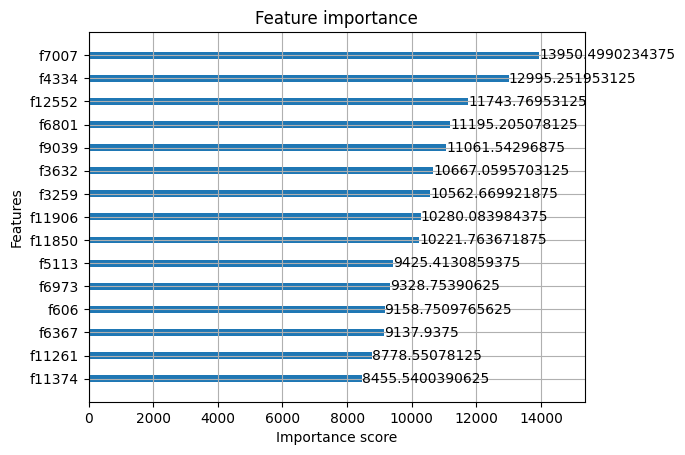

In [51]:
from xgboost import plot_importance
from matplotlib import pyplot
#best_model = pickle.load(open("Oil_kfold_10_tt_from_all.pickle.dat", "rb"))
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

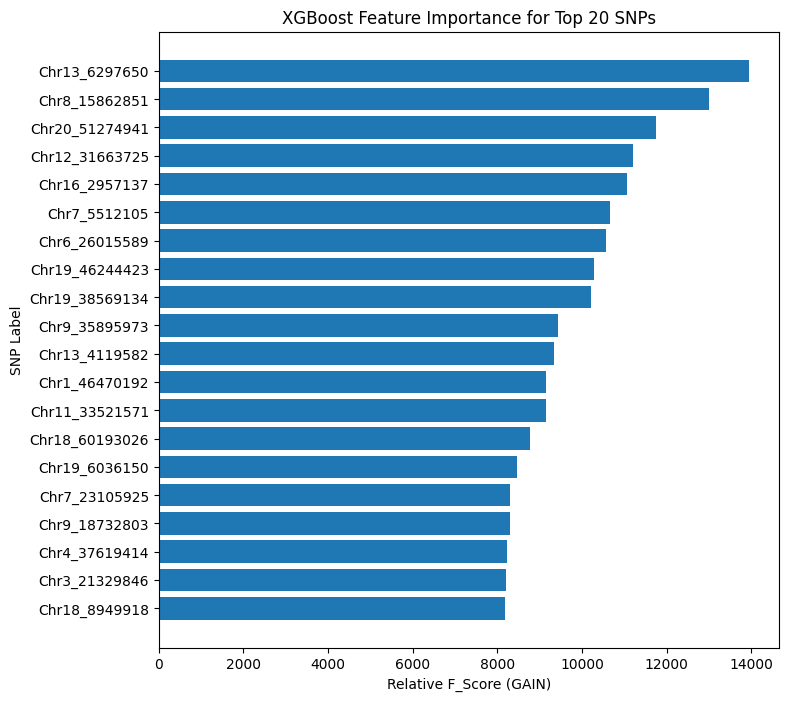

In [52]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_all_dupe, top_n=20)

In [53]:
explainer = shap.Explainer(best_xgbr_model)

In [54]:
shap_values = explainer(gwas_all_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

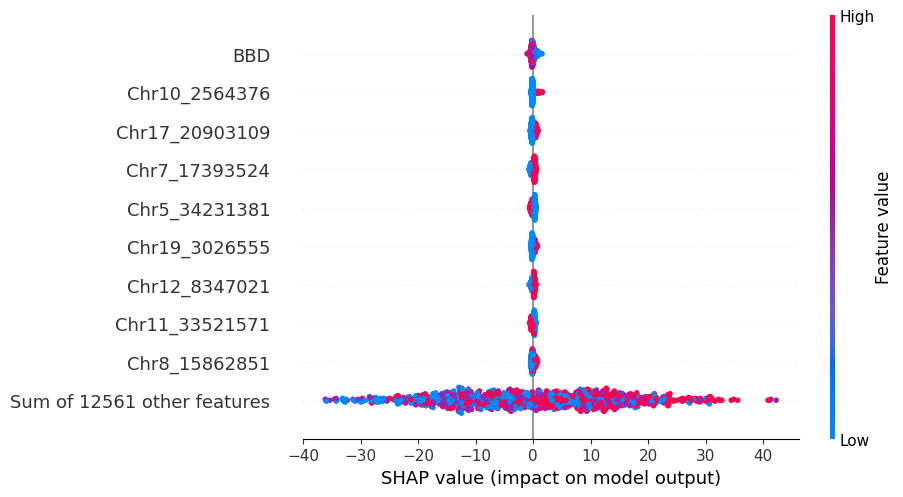

In [55]:
shap.plots.beeswarm(shap_values, show=False)

In [56]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [57]:
holdout_data = holdout_data.set_index('Line')

In [58]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [59]:
X_holdout = holdout_data.iloc[:, 0:251238]

In [60]:
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [61]:
y_holdout = holdout_data.iloc[:, 251238:]

In [62]:
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [63]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [64]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 12570 entries, Chr1_17750 to landrace
dtypes: float64(3), int64(12567)
memory usage: 26.3+ MB


In [65]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -3.18
RMSE of Holdout: 24.14
Mean of Holdout: 355.60
This is 6.79% of the mean pheno data
0 355.712 359.8981
1 344.136 348.6491
2 351.481 364.9679
3 353.611 375.278
4 390.342 344.95477
5 358.958 353.62457


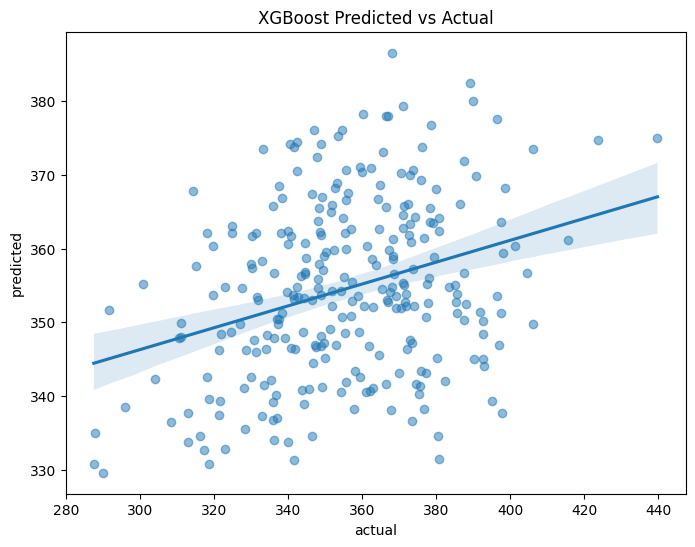

In [71]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [72]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])

0 355.712 359.8981
1 344.136 348.6491
2 351.481 364.9679
3 353.611 375.278
4 390.342 344.95477
5 358.958 353.62457


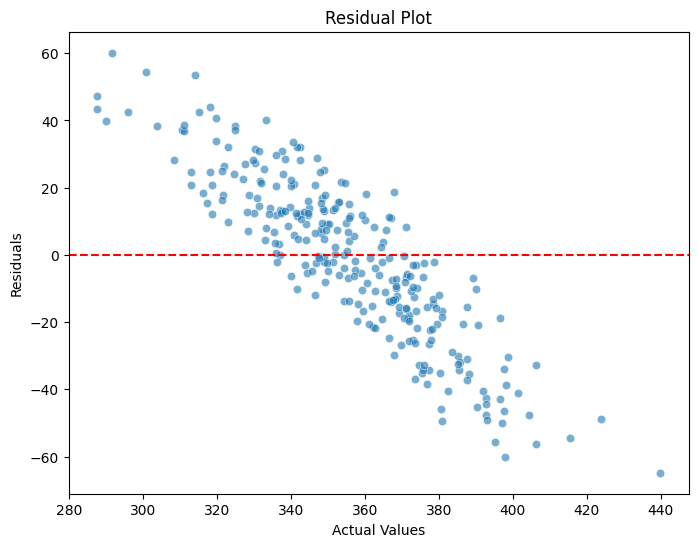

In [73]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [74]:
#### RF models

In [75]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 34), ('max_features', 'sqrt'), ('max_samples', 0.9995085462994528), ('min_samples_leaf', 7), ('min_samples_split', 7), ('n_estimators', 240)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 34), ('max_features', 'sqrt'), ('max_samples', 0.9995085462994528), ('min_samples_leaf', 7), ('min_samples_split', 7), ('n_estimators', 240)])

In [76]:
best_rfr_model = eval_k_fold(best_rfreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.38856906337648
RMSE for dataset is:23.409762503439826& mean of this fold is 353.3123727272727
this is 6.6257975407813365% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.090169617888124
RMSE for dataset is:21.105634082545933& mean of this fold is 357.1809727272727
this is 5.9089469188106065% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.574415858032423
RMSE for dataset is:22.9023432229476& mean of this fold is 353.74289999999996
this is 6.474290571753554% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -7.751259701288793
RMSE for dataset is:23.303417873931565& mean of this fold is 357.4582181818182
this is 6.519200479558837% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.12526965629283
RMSE for datase

In [77]:
pickle.dump(best_rfr_model, open("gwas_top5_allfeats_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -6.45
RMSE of Holdout: 23.35
Mean of Holdout: 355.60
This is 6.57% of the mean pheno data
0 355.712 361.163914144074
1 344.136 352.88781499887784
2 351.481 359.8307535157691
3 353.611 365.581431062065
4 390.342 358.0067862379679
5 358.958 358.1786106135676


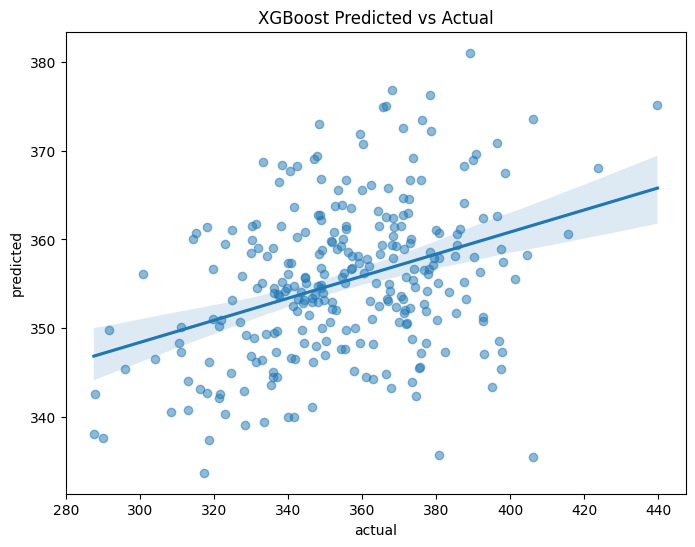

In [78]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [79]:
from sklearn.svm import SVR
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [80]:
#gwas_all = gwas_all.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_all, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.05574886122089939
RMSE for dataset is:23.08001042383665& mean of this fold is 354.2914727272728
this is 6.514413188150094% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.07896672240859082
RMSE for dataset is:19.859835482731537& mean of this fold is 354.7285909090908
this is 5.598600166914986% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5882933012886802
RMSE for dataset is:23.0182780905906& mean of this fold is 352.1327999999999
this is 6.536817385540513% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.33915309490819245
RMSE for dataset is:22.87977804428977& mean of this fold is 357.04071818181825
this is 6.408170519262328% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.5595634058807861
RMSE for 

In [81]:
pickle.dump(best_svr_model, open("gwas_top5_allfeats_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -0.78
RMSE of Holdout: 26.98
Mean of Holdout: 355.60
This is 7.59% of the mean pheno data
0 355.712 387.02039148515513
1 344.136 347.30800702631115
2 351.481 369.51408688102356
3 353.611 374.0512959993941
4 390.342 348.06569476966433
5 358.958 358.27657780337023


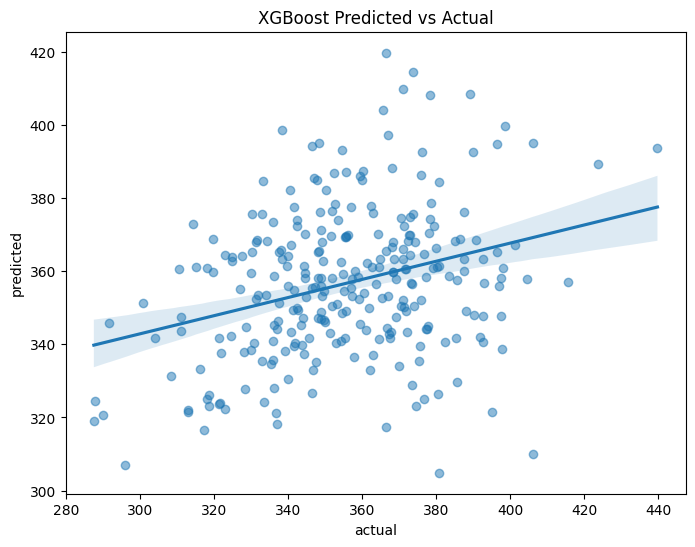

In [82]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only SNPs

In [83]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 12571 entries, Chr1_17750 to PRT
dtypes: float64(4), int64(12567)
memory usage: 105.0+ MB


In [88]:
gwas_snps = gwas_data.iloc[:, 0:12561]
gwas_snps.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_51124213,Chr20_51274941,Chr20_51322653,Chr20_51326016,Chr20_51476391,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s101,0,0,0,0,0,0,0,1,1,0,...,2,1,1,0,0,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0


In [85]:
gwas_snps_dupe = gwas_data.iloc[:, 0:12561]
gwas_snps_dupe.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_51124213,Chr20_51274941,Chr20_51322653,Chr20_51326016,Chr20_51476391,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s100,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s101,0,0,0,0,0,0,0,1,1,0,...,2,1,1,0,0,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
s1014,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0


In [86]:
gwas_y = gwas_data.iloc[:, 12570:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


# Run models

In [89]:
X_train, X_test, y_train, y_test = train_test_split(gwas_snps, gwas_y, test_size=0.1, random_state=42)

In [90]:
X_train.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_51124213,Chr20_51274941,Chr20_51322653,Chr20_51326016,Chr20_51476391,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655
Line,,,,,,,,,,,,,,,,,,,,,
s174,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
s623,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
s237,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
s73,0,0,0,0,0,0,0,0,0,0,...,2,2,0,0,0,0,0,0,0,2
s195,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0


In [91]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [92]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4825958805302847), ('colsample_bytree', 0.4397816411246381), ('gamma', 2.0910817152625037e-05), ('learning_rate', 0.05018601860941885), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 195), ('reg_alpha', 1.598943412668339e-08), ('reg_lambda', 1.1454274579395227e-07), ('subsample', 0.1536154650973617)])


In [54]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.4825958805302847), ('colsample_bytree', 0.4397816411246381), ('gamma', 2.0910817152625037e-05), ('learning_rate', 0.05018601860941885), ('max_delta_step', 12), ('max_depth', 50), ('min_child_weight', 4), ('n_estimators', 195), ('reg_alpha', 1.598943412668339e-08), ('reg_lambda', 1.1454274579395227e-07), ('subsample', 0.1536154650973617)])

OrderedDict([('colsample_bylevel', 0.9132100359267209), ('colsample_bytree', 0.7679711803126804), ('gamma', 2.428808912219129e-07), ('learning_rate', 0.03511167856740689), ('max_delta_step', 3), ('max_depth', 8), ('min_child_weight', 4), ('n_estimators', 197), ('reg_alpha', 0.023358352781682152), ('reg_lambda', 2.1396512525873352e-07), ('scale_pos_weight', 0.001760608876847004), ('subsample', 0.15990388740095085)])


In [93]:
gwas_snps = gwas_snps.to_numpy()
gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.5635154042803339
RMSE for dataset is:24.316999840792025& mean of this fold is 353.8721909090908
this is 6.871689967590311% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.3149719874770422
RMSE for dataset is:22.085743941266134& mean of this fold is 355.9995545454546
this is 6.2038684204157315% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.4497593503580553
RMSE for dataset is:21.743807693124953& mean of this fold is 356.79771818181814
this is 6.094155479448631% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.0953422841833986
RMSE for dataset is:21.549520024875516& mean of this fold is 352.50239999999997
this is 6.113297391698757% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.0739601306565683
RMSE f

In [94]:
pickle.dump(best_xgbr_model, open("gwas_top5_onlysnps_xgbr_prt.pickle.dat", "wb"))

<Figure size 2000x2000 with 0 Axes>

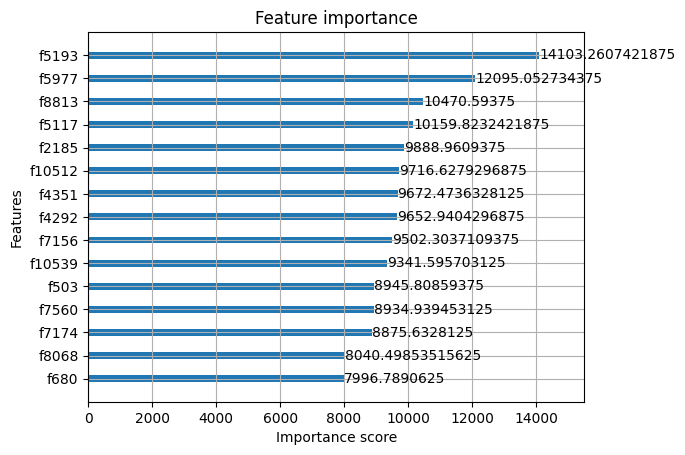

In [95]:
from xgboost import plot_importance
from matplotlib import pyplot
#best_model = pickle.load(open("Oil_kfold_10_tt_from_all.pickle.dat", "rb"))
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

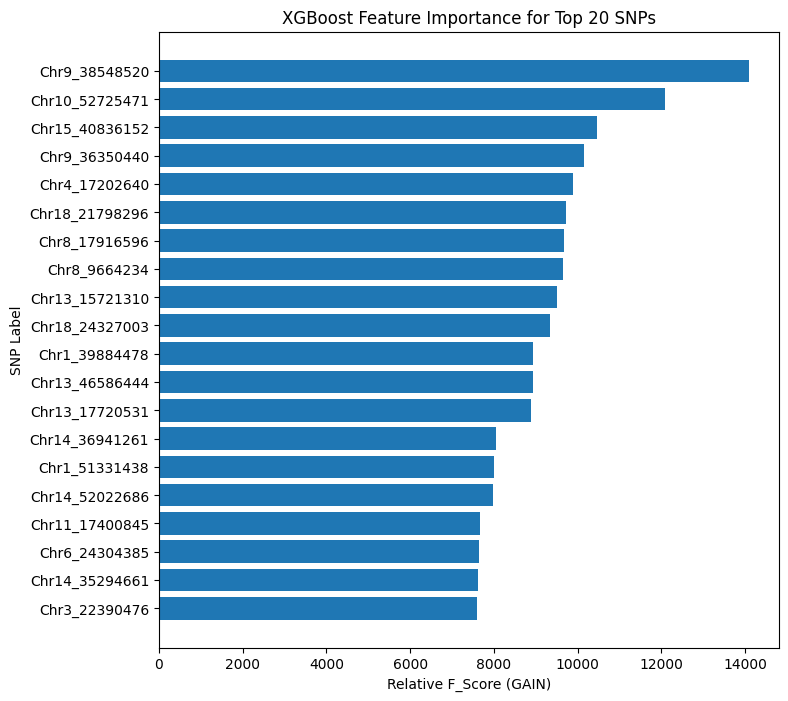

In [96]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_snps_dupe , top_n=20)

In [97]:
explainer = shap.Explainer(best_xgbr_model)

In [98]:
shap_values = explainer(gwas_snps_dupe)

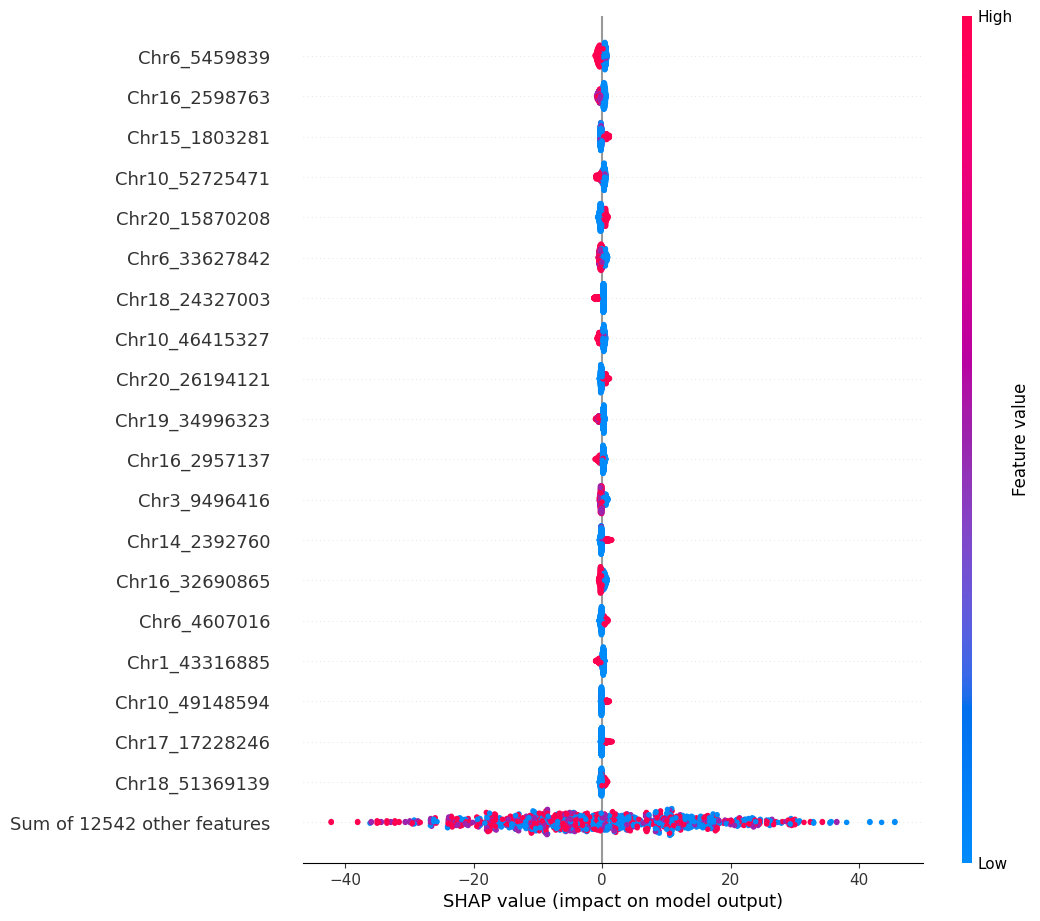

In [99]:
shap.plots.beeswarm(shap_values,20, plot_size=[10,11])


In [100]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [101]:
holdout_data = holdout_data.set_index('Line')

In [104]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [105]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [106]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [107]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 12561 entries, Chr1_17750 to Chr20_52241655
dtypes: int64(12561)
memory usage: 26.3+ MB


In [108]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -2.08
RMSE of Holdout: 24.63
Mean of Holdout: 355.60
This is 6.93% of the mean pheno data
0 355.712 361.2781
1 344.136 362.12018
2 351.481 372.23648
3 353.611 374.28397
4 390.342 347.17905
5 358.958 349.89688


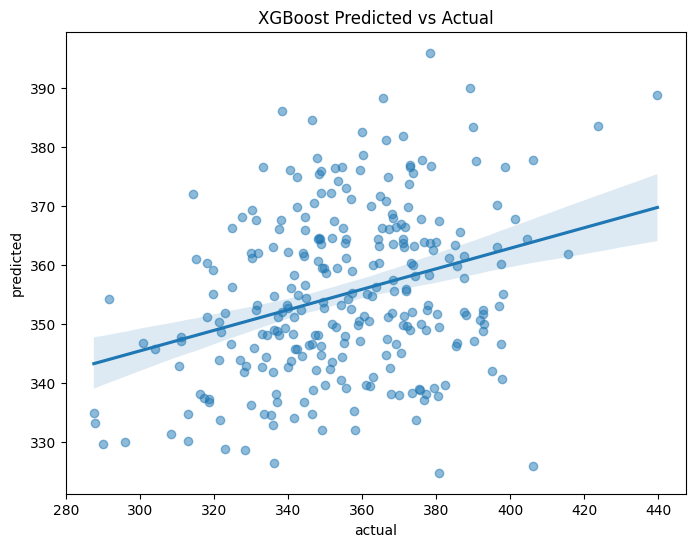

In [109]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [110]:
#### RF models

In [111]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.8010193643534305), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 492)])


In [ ]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 50), ('max_features', 'sqrt'), ('max_samples', 0.8010193643534305), ('min_samples_leaf', 1), ('min_samples_split', 20), ('n_estimators', 492)])

In [112]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.8624042868051642
RMSE for dataset is:19.754819671717424& mean of this fold is 355.91319090909093
this is 5.550460105527051% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.978840259423586
RMSE for dataset is:21.762695292187836& mean of this fold is 353.75948181818194
this is 6.151833777100844% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.194454885988008
RMSE for dataset is:23.233637150815746& mean of this fold is 354.00008181818174
this is 6.563172819476576% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.648092513559659
RMSE for dataset is:22.562300095957017& mean of this fold is 355.35574545454546
this is 6.349214944336118% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -5.895760934527487
RMSE for 

In [113]:
pickle.dump(best_rfr_model, open("gwas_top5_onlysnps_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -5.95
RMSE of Holdout: 23.45
Mean of Holdout: 355.60
This is 6.60% of the mean pheno data
0 355.712 361.52200063548827
1 344.136 352.07754950220595
2 351.481 363.1147498254687
3 353.611 366.2712247168183
4 390.342 357.66604029757207
5 358.958 358.0636668223319


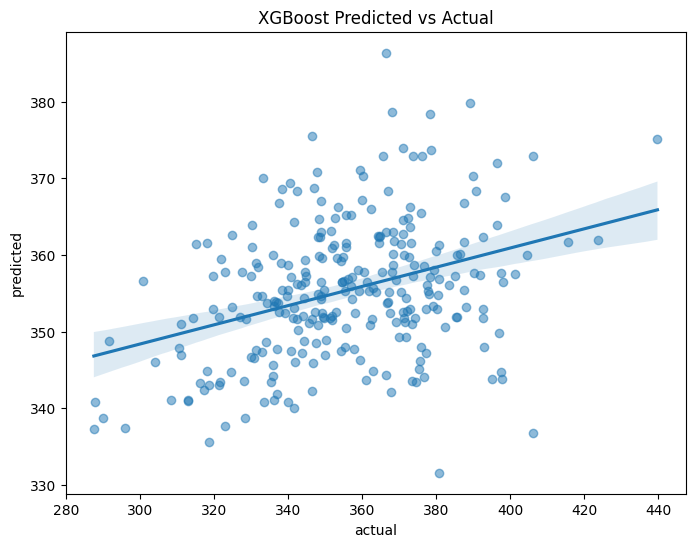

In [114]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [115]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [116]:
#gwas_snps = gwas_snps.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_snps, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.3179218341393253
RMSE for dataset is:23.25058614349921& mean of this fold is 354.22147272727267
this is 6.563855647847933% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.03921829944598865
RMSE for dataset is:18.762039714941277& mean of this fold is 356.97898181818175
this is 5.255782740872192% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.15302698372063483
RMSE for dataset is:21.89874887187719& mean of this fold is 352.0564363636364
this is 6.220238180579132% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.039123451739393245
RMSE for dataset is:24.15616635489927& mean of this fold is 353.4420545454546
this is 6.834547854234661% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.34310981173311017
RMSE 

In [117]:
pickle.dump(best_svr_model, open("gwas_top5_onlysnps_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -1.01
RMSE of Holdout: 26.68
Mean of Holdout: 355.60
This is 7.50% of the mean pheno data
0 355.712 356.3297123488956
1 344.136 348.6008563345333
2 351.481 368.42996540273185
3 353.611 372.15910434299235
4 390.342 345.18403465673623
5 358.958 359.1638032354723


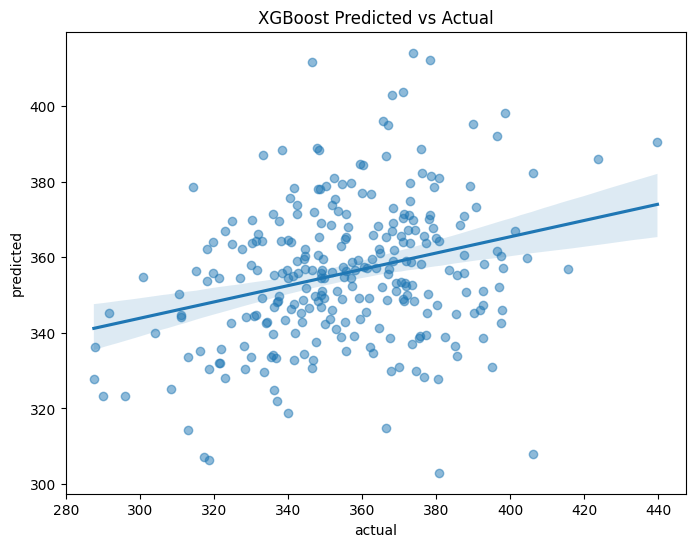

In [118]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

# GWAS only location

In [119]:
gwas_loc= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
gwas_loc.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
s101,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [120]:
gwas_loc_dupe= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'PRT'], axis=1)
gwas_loc_dupe.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
s101,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


In [121]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1094 entries, s100 to s99
Columns: 12566 entries, Chr1_17750 to landrace
dtypes: int64(12566)
memory usage: 104.9+ MB


In [124]:
gwas_y = gwas_data.iloc[:, 12570:]
gwas_y.head()

,PRT
Line,
s100,340.553
s100,358.104
s101,385.915
s1014,366.116
s1014,326.667


# Run models

In [125]:
X_train, X_test, y_train, y_test = train_test_split(gwas_loc, gwas_y, test_size=0.1, random_state=42)

In [126]:
X_train.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s174,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,1,0
s623,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
s237,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
s73,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,1,0,0,1,0
s195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0


In [127]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [128]:
print(y_train[~np.isfinite(y_train)])

[]


In [129]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5131849385896041), ('colsample_bytree', 0.5027481092728995), ('gamma', 0.002787763618833371), ('learning_rate', 0.04687787199576034), ('max_delta_step', 10), ('max_depth', 36), ('min_child_weight', 4), ('n_estimators', 171), ('reg_alpha', 8.119918764834324e-07), ('reg_lambda', 6.224447731572729e-06), ('subsample', 0.13618073622490334)])


In [70]:
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.5131849385896041), ('colsample_bytree', 0.5027481092728995), ('gamma', 0.002787763618833371), ('learning_rate', 0.04687787199576034), ('max_delta_step', 10), ('max_depth', 36), ('min_child_weight', 4), ('n_estimators', 171), ('reg_alpha', 8.119918764834324e-07), ('reg_lambda', 6.224447731572729e-06), ('subsample', 0.13618073622490334)])

OrderedDict([('colsample_bylevel', 0.4160029192647807), ('colsample_bytree', 0.7304484857455519), ('gamma', 0.13031389926541354), ('learning_rate', 0.042815319280763466), ('max_delta_step', 13), ('max_depth', 21), ('min_child_weight', 2), ('n_estimators', 161), ('reg_alpha', 5.497557739289786e-07), ('reg_lambda', 0.05936070635912049), ('scale_pos_weight', 0.060830282487222144), ('subsample', 0.13556548021189216)])


In [158]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_xgbr_model = eval_k_fold(best_xgbreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.280845785229546
RMSE for dataset is:17.921509421651447& mean of this fold is 352.78285454545454
this is 5.080039800897506% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.077669894095125
RMSE for dataset is:19.655552990276536& mean of this fold is 356.90970909090896
this is 5.507149984891569% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.613986072901969
RMSE for dataset is:21.53520360575098& mean of this fold is 355.6831
this is 6.054604114097908% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -1.5305155540147788
RMSE for dataset is:19.76152542913786& mean of this fold is 355.33733636363644
this is 5.561342253355215% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.8392315744143146
RMSE for dataset is:

In [160]:
pickle.dump(best_xgbr_model, open("gwas_top5_onlyloc_xgbr_prt.pickle.dat", "wb"))
#best_xgbr_model = pickle.load(open("gwas_top5_onlyloc_xgbr_md.pickle.dat", "rb"))

<Figure size 2000x2000 with 0 Axes>

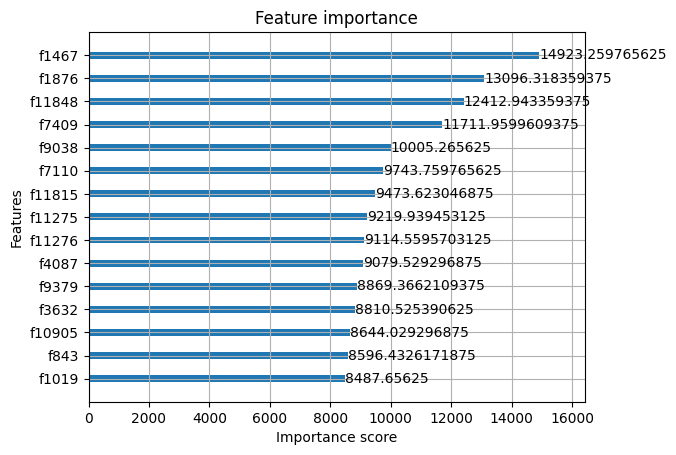

In [161]:
from xgboost import plot_importance
from matplotlib import pyplot
plt.figure(figsize = (20, 20))
plot_importance(best_xgbr_model, max_num_features=15, importance_type='gain', height=0.3)
pyplot.show()

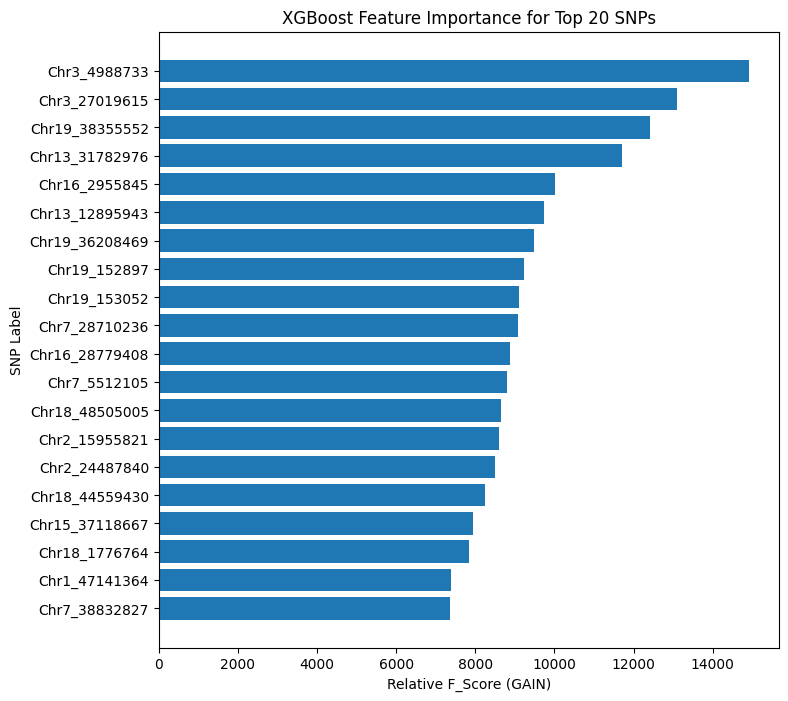

In [162]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, gwas_loc_dupe, top_n=20)

In [163]:
explainer = shap.Explainer(best_xgbr_model)

In [164]:
shap_values = explainer(gwas_loc_dupe)

<Axes: xlabel='SHAP value (impact on model output)'>

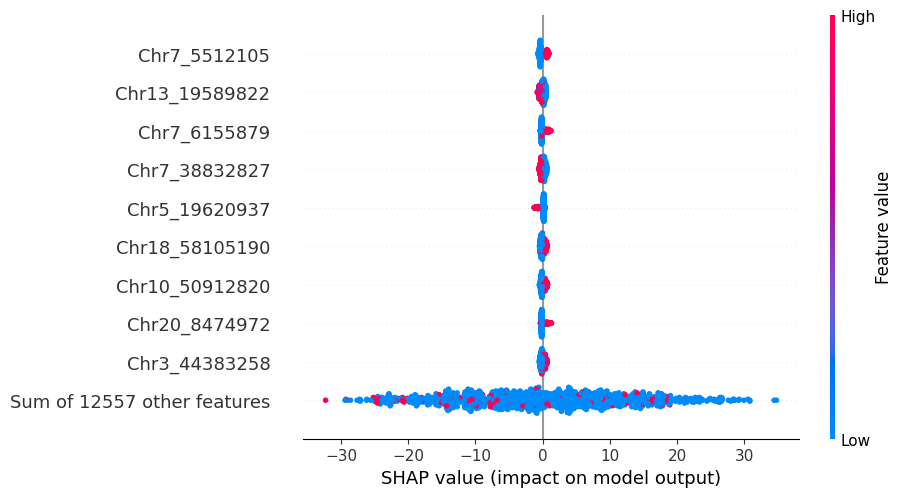

In [165]:
shap.plots.beeswarm(shap_values, show=False)

In [137]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_prt.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
new_line,,,,,,,,,,,,,,,,,,,,,
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102_HeiLongJiang_2014,s102,2,0,0,0,0,0,0,1,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110_BeiJing_2013,s110,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112_BeiJing_2013,s112,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113_BeiJing_2013,s113,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [138]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace,PRT
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,39,6.53333,8.93333,52.7333,1,0,0,0,1,355.712
s102,2,0,0,0,0,0,0,1,0,0,...,55,5.37333,7.92000,48.2000,0,0,1,0,1,344.136
s110,0,0,0,0,0,0,0,0,0,0,...,98,7.00000,9.63333,96.0333,1,0,0,0,1,351.481
s112,0,0,0,0,0,0,0,0,0,0,...,98,8.20000,10.43330,89.4667,1,0,0,0,1,353.611
s113,0,0,0,0,0,0,0,0,0,0,...,64,6.33333,9.50000,66.1000,1,0,0,0,1,390.342


In [139]:
X_holdout = holdout_data.iloc[:, 0:251238]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,Chr20_52270629,BBD,LW,LL,PLH,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,1,0,0,1,1,0,0,0,...,0,39,6.53333,8.93333,52.7333,1,0,0,0,1
s102,2,0,0,0,0,0,0,1,0,0,...,0,55,5.37333,7.92000,48.2000,0,0,1,0,1
s110,0,0,0,0,0,0,0,0,0,0,...,0,98,7.00000,9.63333,96.0333,1,0,0,0,1
s112,0,0,0,0,0,0,0,0,0,0,...,0,98,8.20000,10.43330,89.4667,1,0,0,0,1
s113,0,0,0,0,0,0,0,0,0,0,...,0,64,6.33333,9.50000,66.1000,1,0,0,0,1


In [140]:
y_holdout = holdout_data.iloc[:, 251238:]
y_holdout.head()

,PRT
Line,
s101,355.712
s102,344.136
s110,351.481
s112,353.611
s113,390.342


In [141]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [142]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274 entries, s101 to s99
Columns: 12566 entries, Chr1_17750 to landrace
dtypes: int64(12566)
memory usage: 26.3+ MB


In [143]:
X_holdout.head()

,Chr1_17750,Chr1_130043,Chr1_131374,Chr1_132416,Chr1_213719,Chr1_213749,Chr1_213796,Chr1_213831,Chr1_215314,Chr1_234732,...,Chr20_51568577,Chr20_51595684,Chr20_51888995,Chr20_51890470,Chr20_52241655,BeiJing_2013,HeNan_2014,HeiLongJiang_2014,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s101,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,1,0,0,0,1
s102,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,1
s110,0,1,0,0,0,0,0,0,0,0,...,0,0,2,0,1,1,0,0,0,1
s112,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
s113,0,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1


In [144]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: -3.58
RMSE of Holdout: 23.76
Mean of Holdout: 355.60
This is 6.68% of the mean pheno data
0 355.712 361.88257
1 344.136 351.28113
2 351.481 364.5598
3 353.611 370.1063
4 390.342 357.485
5 358.958 351.50467


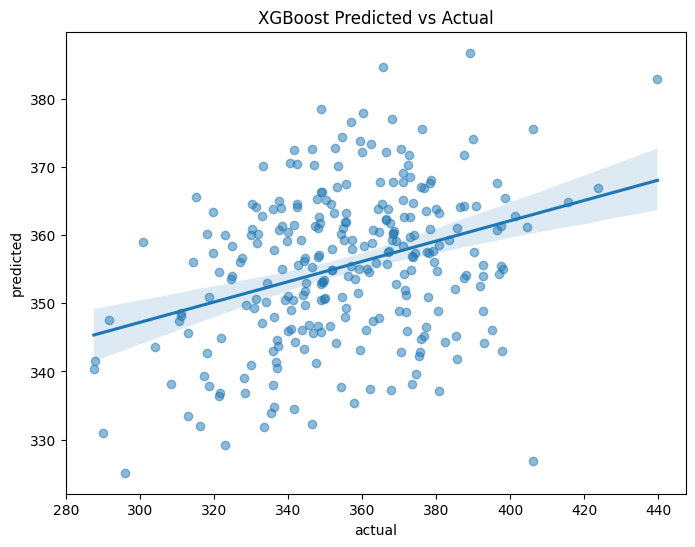

In [159]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [146]:
  # Generate predictions
all_preds = [x for x in best_xgbr_model.predict(X_holdout)]


    
 # Prepare data for residual plot
y_holdout = y_holdout.ravel()
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, all_preds[counter])
    if all_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(all_preds[counter])


0 355.712 358.38763
1 344.136 353.00702
2 351.481 358.5226
3 353.611 369.43732
4 390.342 356.11722
5 358.958 353.58435


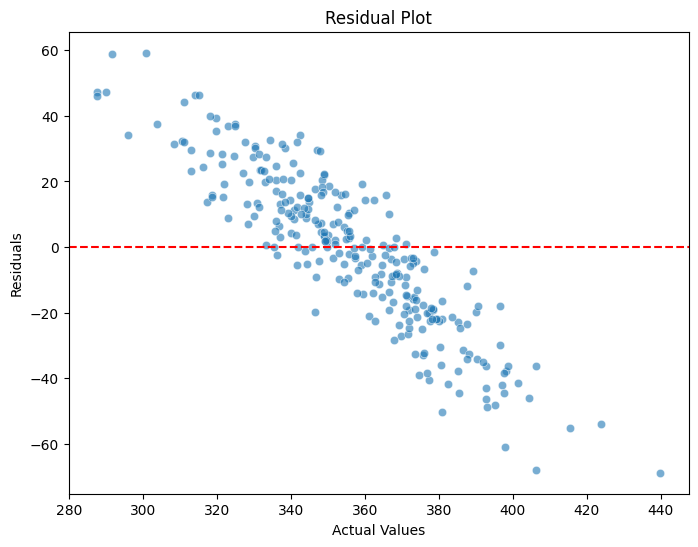

In [147]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot
plt.show()

In [148]:
best_rfreg = bayesian_rfr_search(X_train, y_train, rf_space)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 26), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 2), ('min_samples_split', 18), ('n_estimators', 219)])


In [2]:
Best RF Parameters: OrderedDict([('bootstrap', True), ('max_depth', 26), ('max_features', 'sqrt'), ('max_samples', 1.0), ('min_samples_leaf', 2), ('min_samples_split', 18), ('n_estimators', 219)])

In [150]:
gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_rfr_model = eval_k_fold(best_rfreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -2.892504970442355
RMSE for dataset is:20.117327664862813& mean of this fold is 355.94853636363644
this is 5.651751758942755% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.082224352754551
RMSE for dataset is:22.211862100280715& mean of this fold is 356.2615454545455
this is 6.23470660352667% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -3.548729711440669
RMSE for dataset is:21.824076639267222& mean of this fold is 354.05859090909087
this is 6.163973195292651% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.582494677268645
RMSE for dataset is:21.70664356658576& mean of this fold is 351.2826090909091
this is 6.179253684878051% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -4.042962557978795
RMSE for datas

In [151]:
pickle.dump(best_rfr_model, open("gwas_top5_onlyloc_rfr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -5.16
RMSE of Holdout: 23.12
Mean of Holdout: 355.60
This is 6.50% of the mean pheno data
0 355.712 366.085200000779
1 344.136 352.3560466970931
2 351.481 361.87377950077956
3 353.611 364.5160673589058
4 390.342 357.5279136875524
5 358.958 353.29376780308934


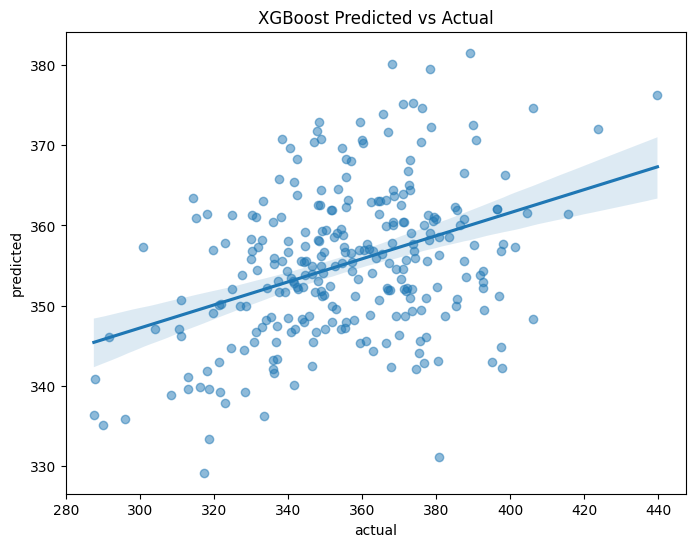

In [152]:
metrics = evaluate_holdout_performance(best_rfr_model, X_holdout, y_holdout)

In [153]:
best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best SVR Parameters: OrderedDict([('epsilon', 2.5), ('kernel', 'linear')])


In [155]:
#gwas_loc = gwas_loc.to_numpy()
#gwas_y = gwas_y.to_numpy() 
best_svr_model = eval_k_fold(best_svreg, gwas_loc, gwas_y, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.41636519152978124
RMSE for dataset is:26.12698739179828& mean of this fold is 353.5973272727273
this is 7.388909750340593% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.0999108971379884
RMSE for dataset is:21.044960416001576& mean of this fold is 356.89808181818177
this is 5.896630295346537% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.12105681486712228
RMSE for dataset is:23.230950820852883& mean of this fold is 353.5102181818182
this is 6.571507590455189% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.28282531773648234
RMSE for dataset is:22.066797361889556& mean of this fold is 358.69672727272734
this is 6.151937189299065% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: -0.27437635397860705
RMSE 

In [156]:
pickle.dump(best_svr_model, open("gwas_top5_onlyloc_svr_prt.pickle.dat", "wb"))

R^2 Value of Holdout: -0.83
RMSE of Holdout: 26.89
Mean of Holdout: 355.60
This is 7.56% of the mean pheno data
0 355.712 395.27741670582503
1 344.136 341.31135838284763
2 351.481 374.393822517257
3 353.611 373.5298270291629
4 390.342 348.57111234751244
5 358.958 351.6854902248811


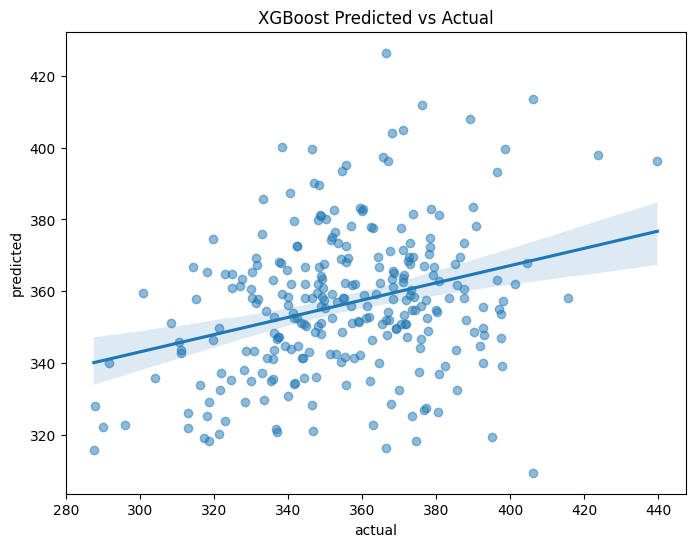

In [157]:
metrics = evaluate_holdout_performance(best_svr_model, X_holdout, y_holdout)

In [74]:
X_holdout.shape

(613, 12568)